#**Linear discrimenant analyser**

Stratified K-Fold Cross-Validation Results:

Fold 1:
Accuracy: 0.8333
Precision: 0.8310
Recall: 0.8333
F1-Score: 0.8298
Confusion Matrix:
[[7 1 1]
 [0 8 0]
 [2 0 5]]

Fold 2:
Accuracy: 0.7917
Precision: 0.8167
Recall: 0.7917
F1-Score: 0.7913
Confusion Matrix:
[[8 0 1]
 [1 7 0]
 [3 0 4]]

Fold 3:
Accuracy: 0.8750
Precision: 0.8773
Recall: 0.8750
F1-Score: 0.8739
Confusion Matrix:
[[7 0 1]
 [0 9 0]
 [2 0 5]]

Fold 4:
Accuracy: 0.8261
Precision: 0.8449
Recall: 0.8261
F1-Score: 0.8293
Confusion Matrix:
[[7 0 1]
 [1 7 0]
 [2 0 5]]

Fold 5:
Accuracy: 0.8696
Precision: 0.8720
Recall: 0.8696
F1-Score: 0.8684
Confusion Matrix:
[[7 0 1]
 [0 8 0]
 [2 0 5]]

Cross-Validation Metrics Summary:
Mean Accuracy: 0.8391
Mean Precision: 0.8484
Mean Recall: 0.8391
Mean F1-Score: 0.8385

Test Set Evaluation:
Accuracy: 0.7500
Precision: 0.7552
Recall: 0.7500
F1-Score: 0.7508
Classification Report:
              precision    recall  f1-score   support

         1.0       0.75      0.67      0.71         9
   

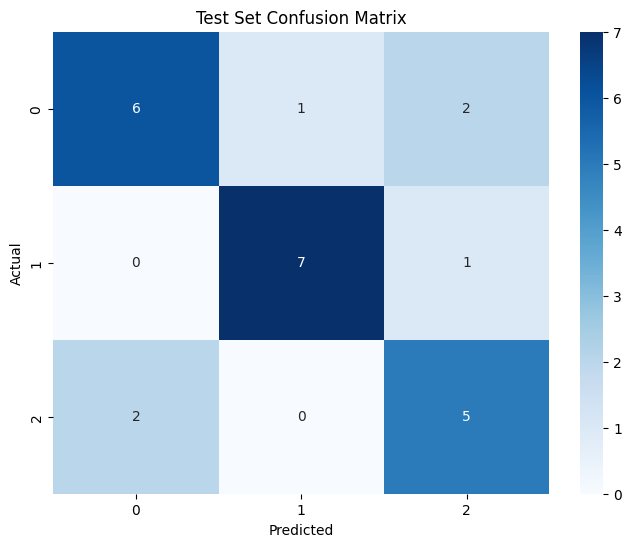

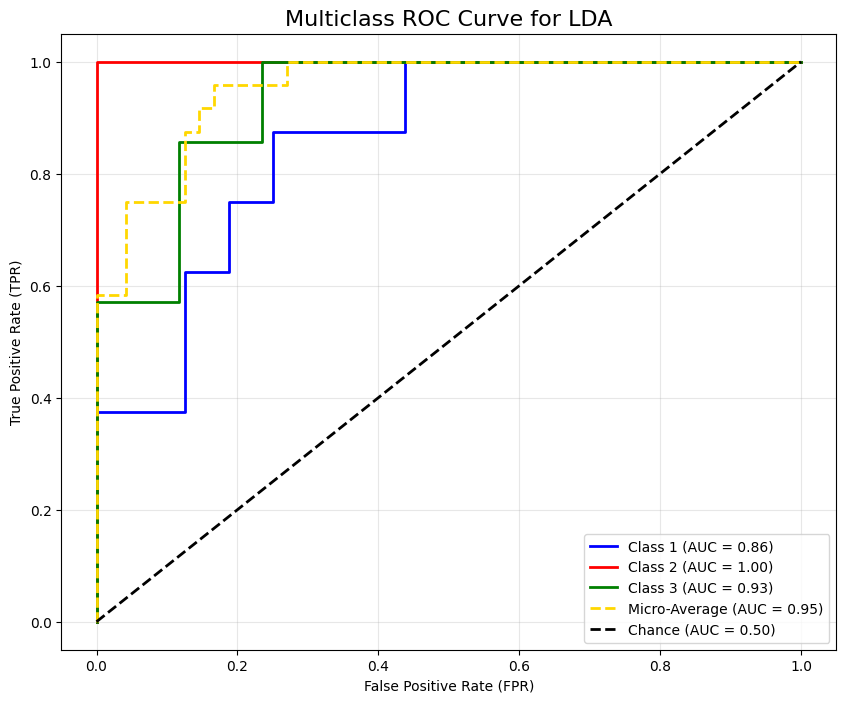

In [ ]:
##############################################################################

import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
icpms = pd.read_excel('/content/dataset icpms(1).xlsx', sheet_name='icpms')
icpms['T'] = icpms['T'].astype(float)

# Define features and target
X = icpms.drop(columns=['T'])
y = icpms['T']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Initialize LDA model
lda_model = LinearDiscriminantAnalysis()

# Perform Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize metrics storage
accuracy_scores, precision_scores, recall_scores, f1_scores = [], [], [], []
confusion_matrices = []

print("Stratified K-Fold Cross-Validation Results:")
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    # Split fold data
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Train and predict
    lda_model.fit(X_train_fold, y_train_fold)
    y_val_pred = lda_model.predict(X_val_fold)

    # Evaluate metrics
    accuracy_scores.append(accuracy_score(y_val_fold, y_val_pred))
    precision_scores.append(precision_score(y_val_fold, y_val_pred, average='weighted'))
    recall_scores.append(recall_score(y_val_fold, y_val_pred, average='weighted'))
    f1_scores.append(f1_score(y_val_fold, y_val_pred, average='weighted'))
    confusion_matrices.append(confusion_matrix(y_val_fold, y_val_pred))

    print(f"\nFold {fold + 1}:")
    print(f"Accuracy: {accuracy_scores[-1]:.4f}")
    print(f"Precision: {precision_scores[-1]:.4f}")
    print(f"Recall: {recall_scores[-1]:.4f}")
    print(f"F1-Score: {f1_scores[-1]:.4f}")
    print(f"Confusion Matrix:\n{confusion_matrices[-1]}")

# Summarize metrics across folds
print("\nCross-Validation Metrics Summary:")
print(f"Mean Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Mean Precision: {np.mean(precision_scores):.4f}")
print(f"Mean Recall: {np.mean(recall_scores):.4f}")
print(f"Mean F1-Score: {np.mean(f1_scores):.4f}")

# Train on full training set and evaluate on test set
lda_model.fit(X_train, y_train)
y_test_pred = lda_model.predict(X_test)

print("\nTest Set Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")

# Confusion matrix visualization
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve for Multiclass (if applicable)
y_binarized = label_binarize(y, classes=np.unique(y))
n_classes = y_binarized.shape[1]

lda_ovr = OneVsRestClassifier(LinearDiscriminantAnalysis())
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X, y_binarized, test_size=0.2, random_state=42
)
lda_ovr.fit(X_train_bin, y_train_bin)
y_score = lda_ovr.decision_function(X_test_bin)

# Compute ROC curve and AUC
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = cycle(["blue", "red", "green", "purple", "orange"])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=f"Class {i + 1} (AUC = {roc_auc[i]:.2f})")

# Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='gold', lw=2, linestyle='--', label=f"Micro-Average (AUC = {roc_auc_micro:.2f})")

# Plot settings
plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Chance (AUC = 0.50)")
plt.title("Multiclass ROC Curve for LDA", fontsize=16)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
##############################################################################

In [ ]:
print("\nCross-Validation Metrics Summary:")
print(f"Mean Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Mean Precision: {np.mean(precision_scores):.4f}")
print(f"Mean Recall: {np.mean(recall_scores):.4f}")
print(f"Mean F1-Score: {np.mean(f1_scores):.4f}")



Cross-Validation Metrics Summary:
Mean Accuracy: 0.8514
Mean Precision: 0.8666
Mean Recall: 0.8514
Mean F1-Score: 0.8543


#**Decision Tree**

Fold 1 Metrics:
  Accuracy: 0.6842
  Precision: 0.6936
  Recall: 0.6842
  F1-Score: 0.6785
Fold 2 Metrics:
  Accuracy: 0.6316
  Precision: 0.6366
  Recall: 0.6316
  F1-Score: 0.6316
Fold 3 Metrics:
  Accuracy: 0.6842
  Precision: 0.6930
  Recall: 0.6842
  F1-Score: 0.6763
Fold 4 Metrics:
  Accuracy: 0.6842
  Precision: 0.7046
  Recall: 0.6842
  F1-Score: 0.6637
Fold 5 Metrics:
  Accuracy: 0.6111
  Precision: 0.6083
  Recall: 0.6111
  F1-Score: 0.5930

Average Metrics Across All Folds:
  Accuracy: 0.6591
  Precision: 0.6672
  Recall: 0.6591
  F1-Score: 0.6486


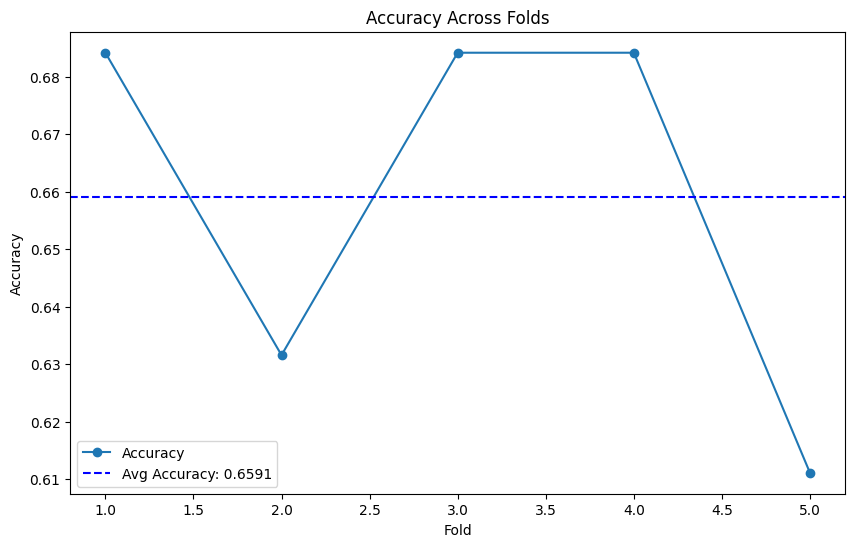


Test Set Metrics:
  Accuracy: 0.6667
  Precision: 0.6712
  Recall: 0.6667
  F1-Score: 0.6625


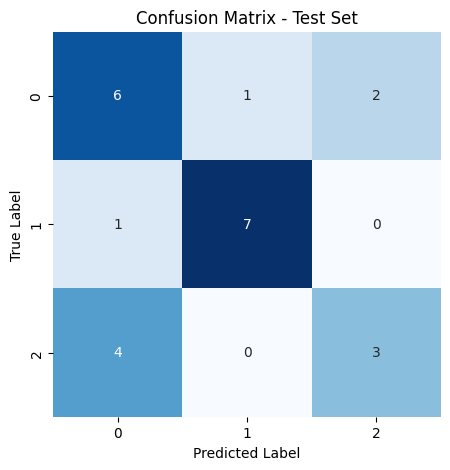

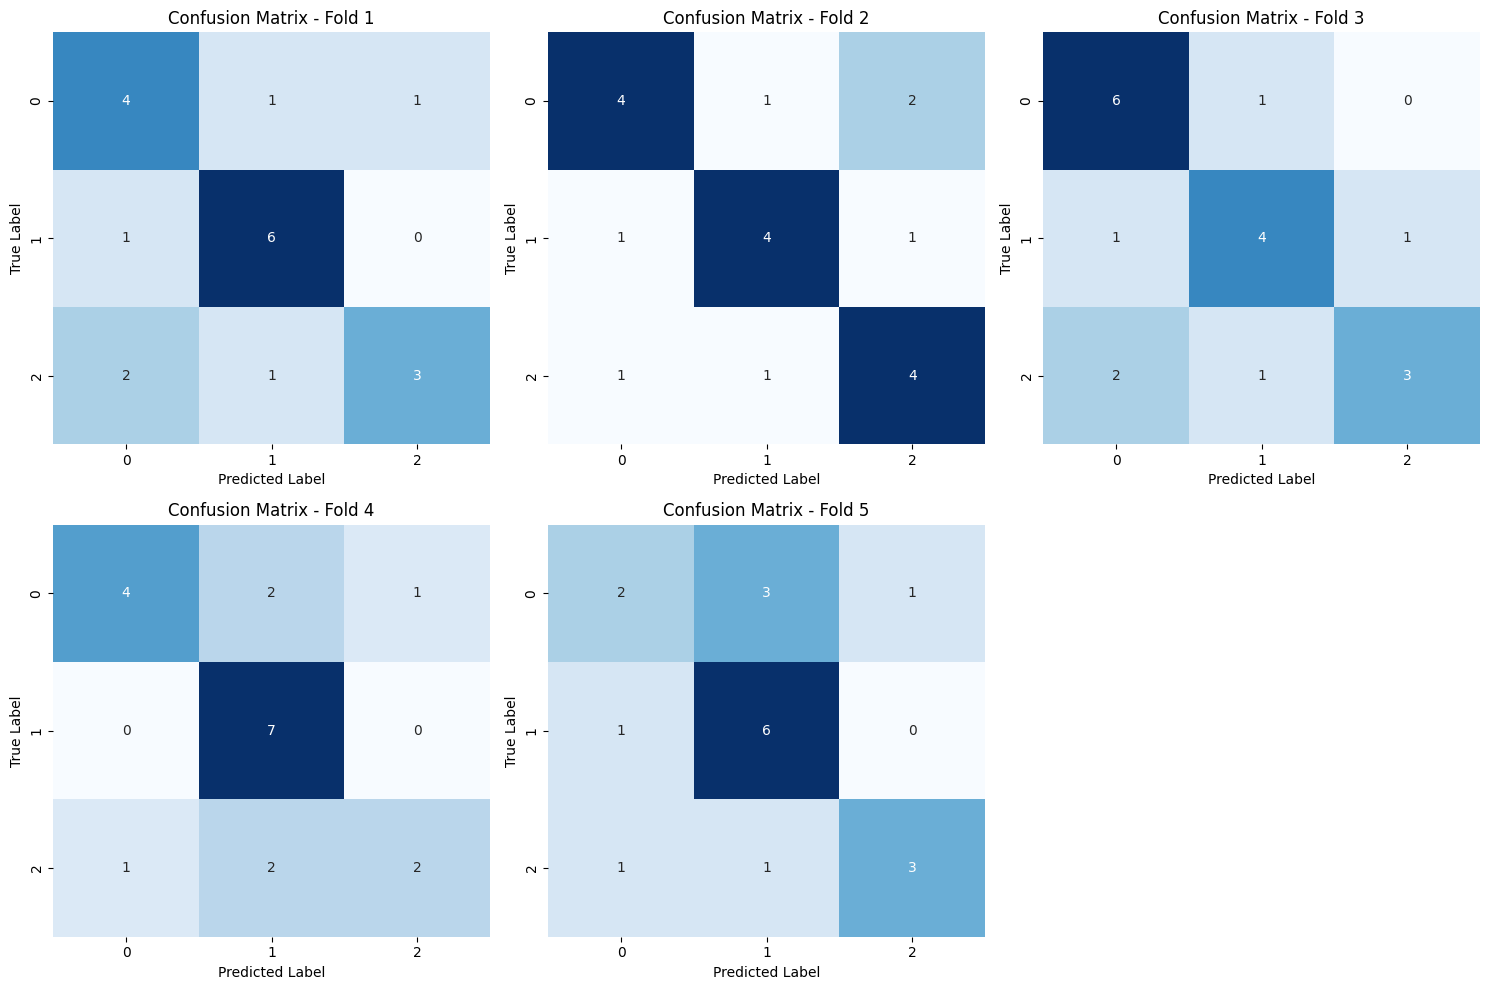

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

########################################
# Data Preparation

# Load dataset (assuming epma2 is already loaded as a DataFrame)
X = icpms.drop(columns=['T'])
y = icpms['T']

# Split into training and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=45
)

########################################
# Model Initialization and Cross-Validation

# Initialize the decision tree classifier
dt_model = DecisionTreeClassifier(criterion='entropy', # Use Gini Impurity for split quality

                                  splitter='random',# Use the best split strategy

                                  max_depth=5,# Limit the tree depth to 5

                                  min_samples_split=10,# Minimum 4 samples needed to split a node

                                  min_samples_leaf=2,# Minimum 2 samples required in a leaf

                                  min_weight_fraction_leaf=0.3,# No weighted fraction constraint for leaf nodes

                                  max_features=None,# Use all features for split

                                  random_state=42,# For reproducibility

                                  max_leaf_nodes=None,# Unlimited leaf nodes

                                  min_impurity_decrease=0.0,# No constraint on minimum impurity decrease

                                  class_weight=None,

                                  )

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='accuracy')

########################################
# Training and Evaluation Function

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    Train and evaluate a DecisionTreeClassifier on the given folds.
    """
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train_fold, y_train_fold)
    y_val_pred = dt_model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    return accuracy, dt_model

########################################
# Cross-Validation Metrics Calculation

fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': []
}
best_model = None
best_accuracy = 0

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Additional metrics
    y_val_pred = model.predict(X_val_fold)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

########################################
# Average Metrics Across Folds

avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

########################################
# Save the Best Model

joblib.dump(best_model, 'best_decision_tree_model.pkl')

########################################
# Visualization of Fold Metrics

# Accuracy Across Folds
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()


########################################
# Test Set Evaluation

y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")


# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

########################################
# Subplots for Cross-Validation Confusion Matrices

num_folds = len(fold_metrics['confusion_matrices'])
cols = 3  # Number of columns in the subplot grid
rows = (num_folds // cols) + (num_folds % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for idx, confusion in enumerate(fold_metrics['confusion_matrices']):
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - Fold {idx + 1}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

# Remove unused subplots if any
for idx in range(len(fold_metrics['confusion_matrices']), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


Fold 1 Metrics:
  Accuracy: 0.6842
  Precision: 0.6936
  Recall: 0.6842
  F1-Score: 0.6785
Fold 2 Metrics:
  Accuracy: 0.6316
  Precision: 0.6366
  Recall: 0.6316
  F1-Score: 0.6316
Fold 3 Metrics:
  Accuracy: 0.6842
  Precision: 0.6930
  Recall: 0.6842
  F1-Score: 0.6763
Fold 4 Metrics:
  Accuracy: 0.6842
  Precision: 0.7046
  Recall: 0.6842
  F1-Score: 0.6637
Fold 5 Metrics:
  Accuracy: 0.6111
  Precision: 0.6083
  Recall: 0.6111
  F1-Score: 0.5930

Average Metrics Across All Folds:
  Accuracy: 0.6591
  Precision: 0.6672
  Recall: 0.6591
  F1-Score: 0.6486


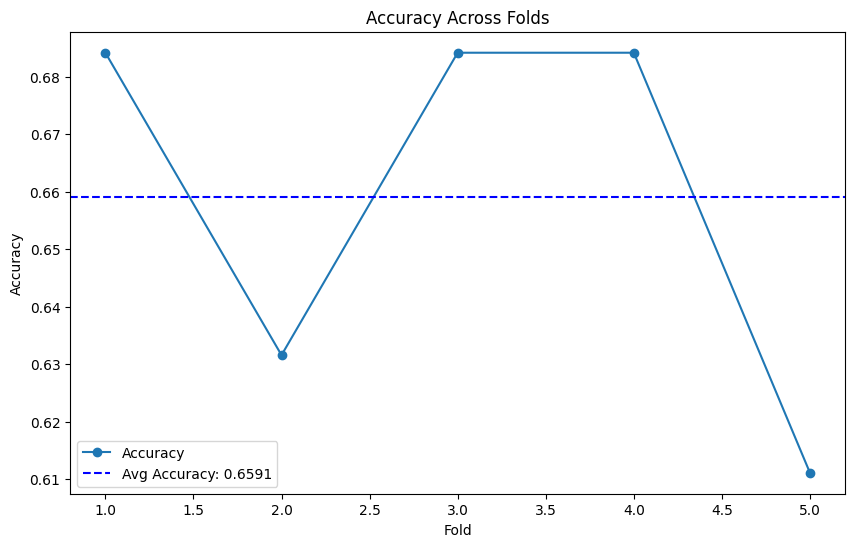


Test Set Metrics:
  Accuracy: 0.6667
  Precision: 0.6712
  Recall: 0.6667
  F1-Score: 0.6625


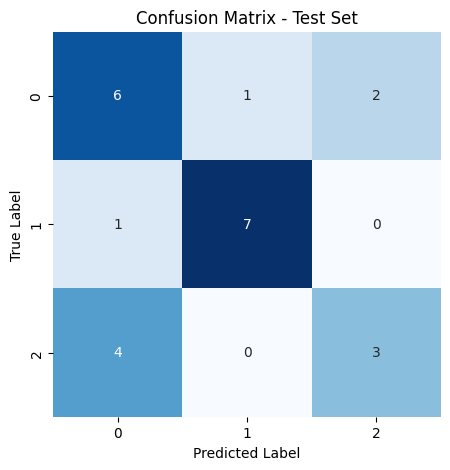

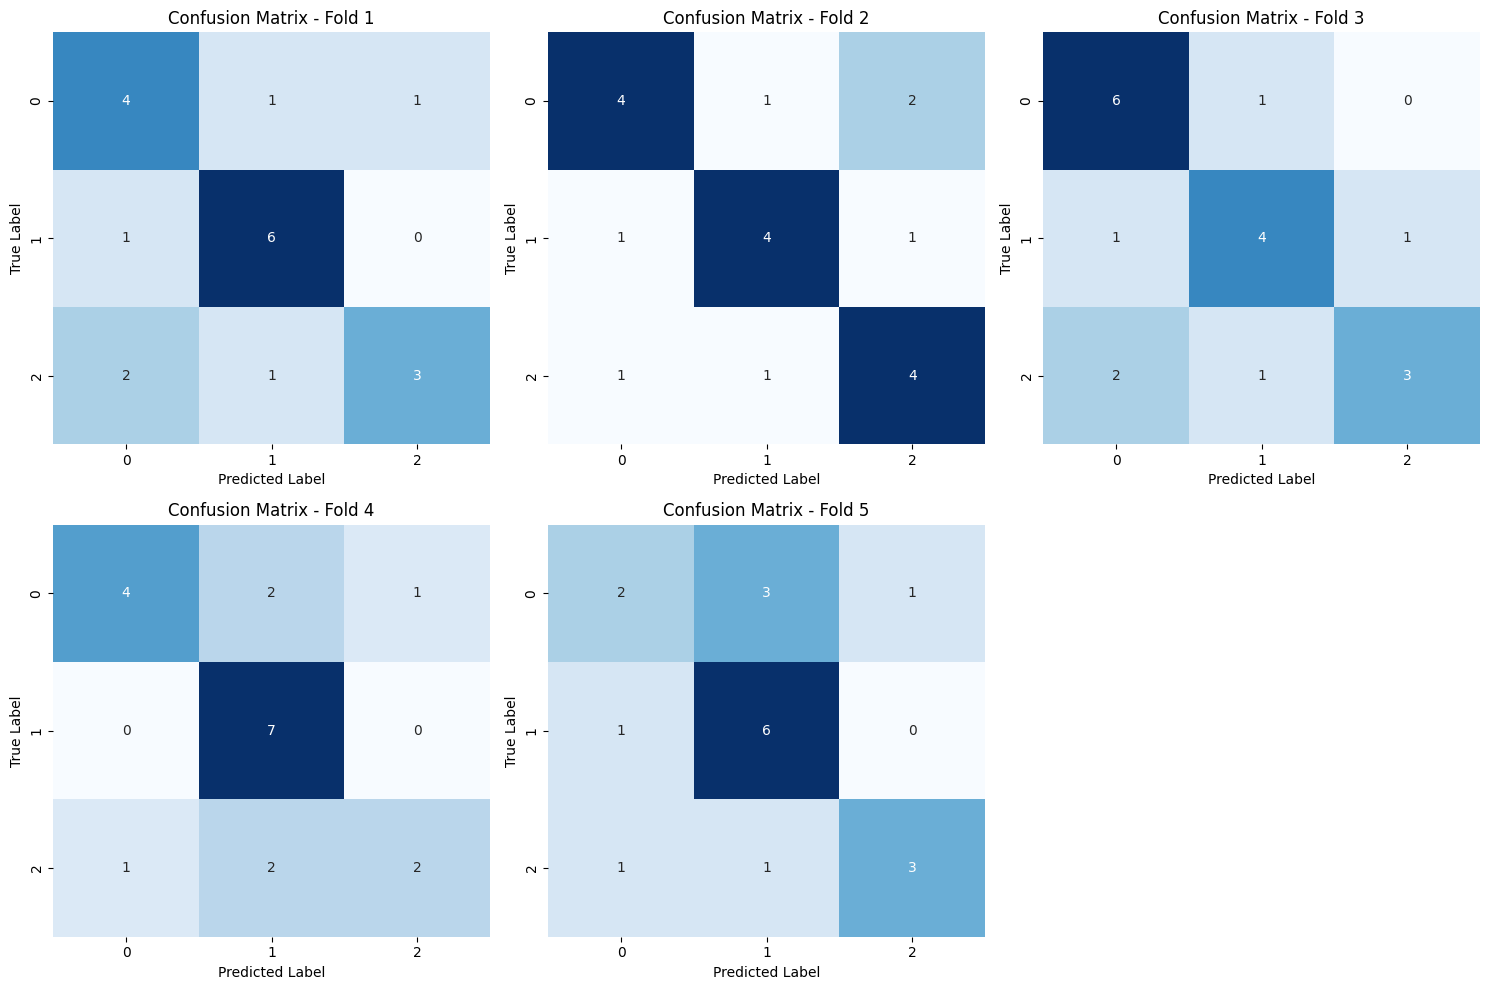

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

########################################
# Data Preparation

# Load dataset (assuming epma2 is already loaded as a DataFrame)
X = icpms.drop(columns=['T'])
y = icpms['T']

# Split into training and test sets (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=45
)

########################################
# Model Initialization and Cross-Validation

# Initialize the decision tree classifier
dt_model = DecisionTreeClassifier(criterion='entropy', # Use Gini Impurity for split quality

                                  splitter='random',# Use the best split strategy

                                  max_depth=5,# Limit the tree depth to 5

                                  min_samples_split=10,# Minimum 4 samples needed to split a node

                                  min_samples_leaf=2,# Minimum 2 samples required in a leaf

                                  min_weight_fraction_leaf=0.3,# No weighted fraction constraint for leaf nodes

                                  max_features=None,# Use all features for split

                                  random_state=42,# For reproducibility

                                  max_leaf_nodes=None,# Unlimited leaf nodes

                                  min_impurity_decrease=0.0,# No constraint on minimum impurity decrease

                                  class_weight=None,

                                  )

# Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dt_model, X_train, y_train, cv=kf, scoring='accuracy')

########################################
# Training and Evaluation Function

def train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold):
    """
    Train and evaluate a DecisionTreeClassifier on the given folds.
    """
    dt_model = DecisionTreeClassifier(random_state=42)
    dt_model.fit(X_train_fold, y_train_fold)
    y_val_pred = dt_model.predict(X_val_fold)
    accuracy = accuracy_score(y_val_fold, y_val_pred)
    return accuracy, dt_model

########################################
# Cross-Validation Metrics Calculation

fold_accuracies = []
fold_metrics = {
    'precision': [],
    'recall': [],
    'f1_score': [],
    'confusion_matrices': []
}
best_model = None
best_accuracy = 0

for fold, (train_index, val_index) in enumerate(kf.split(X_train, y_train)):
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

    accuracy, model = train_and_evaluate(X_train_fold, y_train_fold, X_val_fold, y_val_fold)
    fold_accuracies.append(accuracy)

    # Additional metrics
    y_val_pred = model.predict(X_val_fold)
    precision = precision_score(y_val_fold, y_val_pred, average="weighted")
    recall = recall_score(y_val_fold, y_val_pred, average="weighted")
    f1 = f1_score(y_val_fold, y_val_pred, average="weighted")
    confusion = confusion_matrix(y_val_fold, y_val_pred)

    fold_metrics['precision'].append(precision)
    fold_metrics['recall'].append(recall)
    fold_metrics['f1_score'].append(f1)
    fold_metrics['confusion_matrices'].append(confusion)

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model

    print(f"Fold {fold + 1} Metrics:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

########################################
# Average Metrics Across Folds

avg_accuracy = np.mean(fold_accuracies)
avg_precision = np.mean(fold_metrics['precision'])
avg_recall = np.mean(fold_metrics['recall'])
avg_f1_score = np.mean(fold_metrics['f1_score'])

print("\nAverage Metrics Across All Folds:")
print(f"  Accuracy: {avg_accuracy:.4f}")
print(f"  Precision: {avg_precision:.4f}")
print(f"  Recall: {avg_recall:.4f}")
print(f"  F1-Score: {avg_f1_score:.4f}")

########################################
# Save the Best Model

joblib.dump(best_model, 'best_decision_tree_model.pkl')

########################################
# Visualization of Fold Metrics

# Accuracy Across Folds
folds = range(1, len(fold_accuracies) + 1)
plt.figure(figsize=(10, 6))
plt.plot(folds, fold_accuracies, marker='o', label='Accuracy')
plt.axhline(avg_accuracy, color='blue', linestyle='--', label=f'Avg Accuracy: {avg_accuracy:.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across Folds')
plt.legend()
plt.show()


########################################
# Test Set Evaluation

y_test_pred = best_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted')
test_recall = recall_score(y_test, y_test_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
test_confusion = confusion_matrix(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f"  Accuracy: {test_accuracy:.4f}")
print(f"  Precision: {test_precision:.4f}")
print(f"  Recall: {test_recall:.4f}")
print(f"  F1-Score: {test_f1:.4f}")


# Test Confusion Matrix
plt.figure(figsize=(5, 5))
sns.heatmap(test_confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

########################################
# Subplots for Cross-Validation Confusion Matrices

num_folds = len(fold_metrics['confusion_matrices'])
cols = 3  # Number of columns in the subplot grid
rows = (num_folds // cols) + (num_folds % cols > 0)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # Flatten the axes array for easy indexing

for idx, confusion in enumerate(fold_metrics['confusion_matrices']):
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - Fold {idx + 1}')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

# Remove unused subplots if any
for idx in range(len(fold_metrics['confusion_matrices']), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()


#**ensemble2 LDA and DT**

Accuracy of the ensemble model: 0.71
Accuracy of the Ensemble Model: 0.71

Classification Report:
              precision    recall  f1-score    support
1.0            0.571429  0.888889  0.695652   9.000000
2.0            1.000000  0.875000  0.933333   8.000000
3.0            0.666667  0.285714  0.400000   7.000000
accuracy       0.708333  0.708333  0.708333   0.708333
macro avg      0.746032  0.683201  0.676329  24.000000
weighted avg   0.742063  0.708333  0.688647  24.000000


<Figure size 800x600 with 0 Axes>

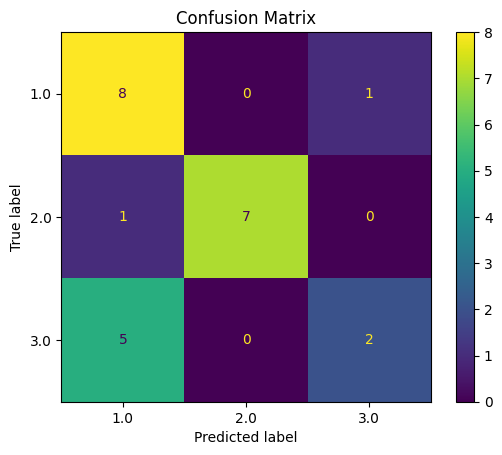

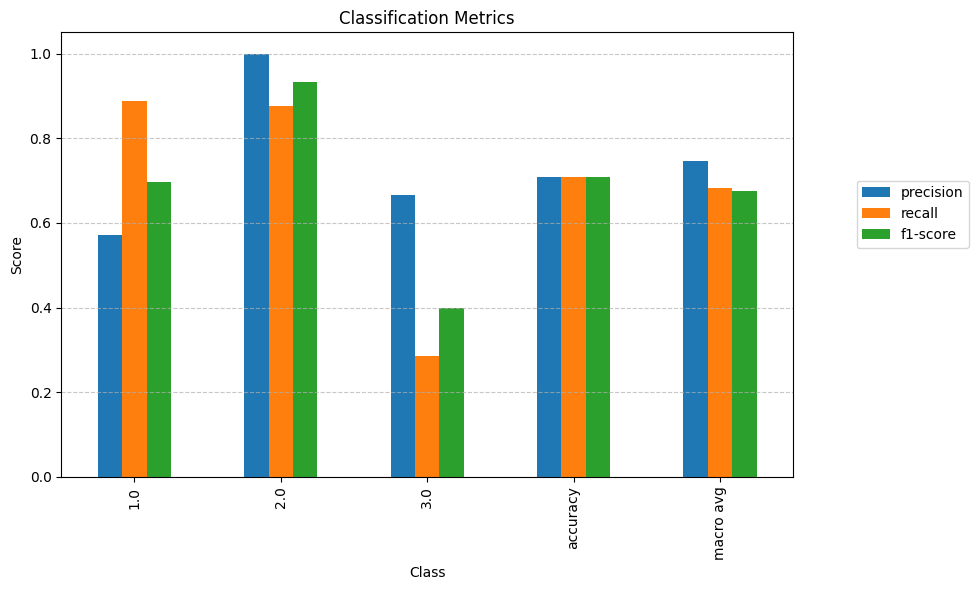

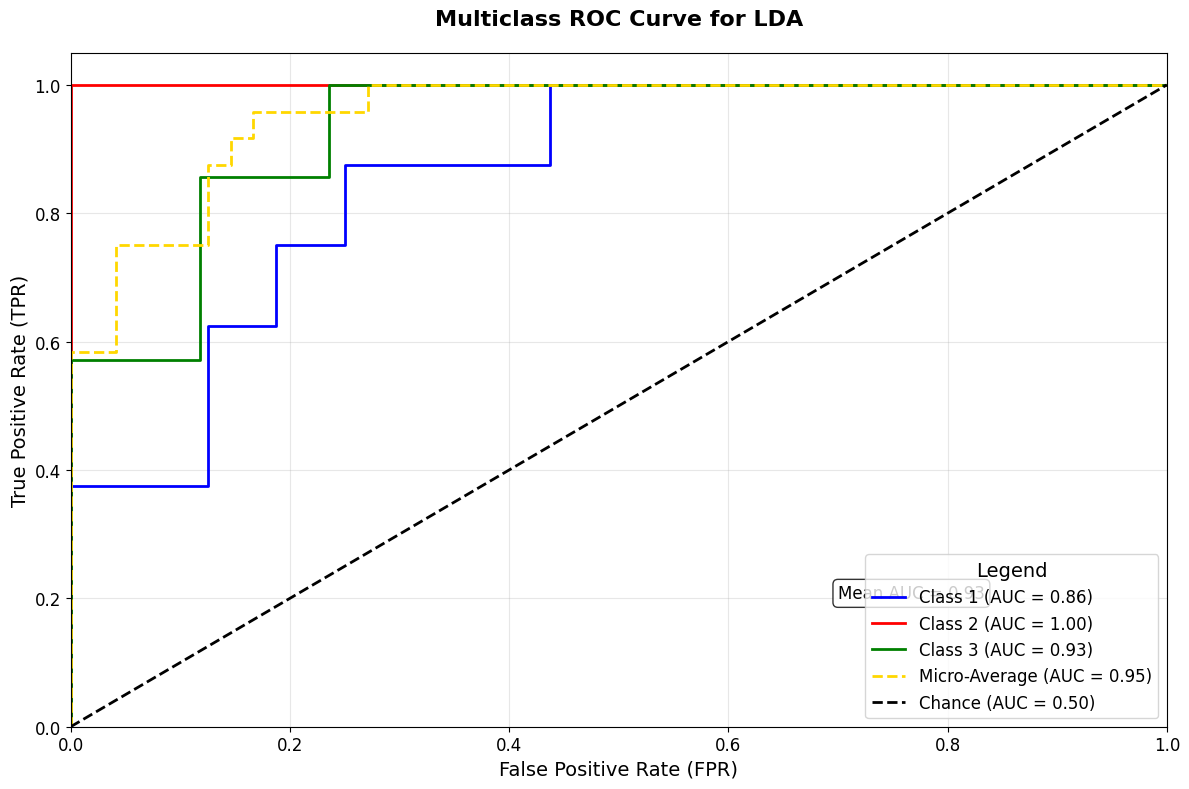

In [ ]:
#ensemble2 LDA and DT

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score

# Assuming 'epma2' is your dataframe and 'T' is your target column

# Example dataset split

X = icpms.drop(columns=['T'])  # Features
y = icpms['T']                # Target label

# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    stratify=y, #applying stratified splitting to ensure proportional representation of target classes in training and test sets.
                                                    test_size=0.2,
                                                    random_state=48)

# Define the individual classifiers

lda = LinearDiscriminantAnalysis(covariance_estimator= None,

                                 n_components=None,

                                 priors=None,

                                 shrinkage= 'auto',

                                 solver= 'lsqr',

                                 store_covariance= False,

                                 tol= 0.0001

                                 )


dt = DecisionTreeClassifier(criterion='gini',              # Use Gini Impurity for split quality

                            splitter='random',             # Use the best split strategy

                            max_depth=5,                   # Limit the tree depth to 5

                            min_samples_split=10,          # Minimum 4 samples needed to split a node

                            min_samples_leaf=2,            # Minimum 2 samples required in a leaf

                            min_weight_fraction_leaf=0.0,  # No weighted fraction constraint for leaf nodes

                            max_features=None,             # Use all features for split

                            random_state=42,               # For reproducibility

                            max_leaf_nodes=None,           # Unlimited leaf nodes

                            min_impurity_decrease=0.0,     # No constraint on minimum impurity decrease

                            class_weight=None,
                            )


# Create an ensemble with max voting

ensemble_model = VotingClassifier(estimators=[
    ('lda', lda),
    ('dt', dt)
], voting='hard')  # 'hard' voting corresponds to max voting

# Train the ensemble model
ensemble_model.fit(X_train, y_train)

# Make predictions
y_pred = ensemble_model.predict(X_test)

# Evaluate the ensemble model
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy of the ensemble model: {accuracy:.2f}")

###########################################################################################################################



import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Generate a classification report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=np.unique(y_test))

# Print performance metrics
print(f"Accuracy of the Ensemble Model: {accuracy:.2f}\n")
print("Classification Report:")
print(report_df)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
disp.plot(cmap='viridis', colorbar=True)
plt.title("Confusion Matrix")
plt.show()

# Optional: Visualize classification report as a bar plot
report_df = report_df.iloc[:-1, :-1]  # Remove 'accuracy' row and 'support' column
report_df.plot(kind='bar', figsize=(10, 6))
plt.title("Classification Metrics")
plt.ylabel("Score")
plt.xlabel("Class")
plt.legend(loc='lower right', bbox_to_anchor=(1.25, 0.5))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


##########################################################################################################################################################


from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np


# Binarize the output for ROC computation
y_binarized = label_binarize(y, classes=np.unique(y))

n_classes = y_binarized.shape[1]

# Initialize the LDA model for one-vs-rest classification
lda_ovr = OneVsRestClassifier(LinearDiscriminantAnalysis())



# Train-test split for ROC analysis
X_train, X_test, y_train, y_test = train_test_split(X, y_binarized, test_size=0.2, random_state=42)



# Fit the model and predict probabilities
lda_ovr.fit(X_train, y_train)
y_score = lda_ovr.decision_function(X_test)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves for each class
plt.figure(figsize=(12, 8))
colors = cycle(["blue", "red", "green", "purple", "orange"])

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"Class {i + 1} (AUC = {roc_auc[i]:.2f})")

# Calculate and plot the micro-average ROC curve (optional for multiclass)
fpr_micro, tpr_micro, _ = roc_curve(y_test.ravel(), y_score.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, color='gold', lw=2, linestyle='--',
         label=f"Micro-Average (AUC = {roc_auc_micro:.2f})")

# Plot diagonal line for reference
plt.plot([0, 1], [0, 1], 'k--', lw=2, label="Chance (AUC = 0.50)")

# Add title and labels
plt.title("Multiclass ROC Curve for LDA", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("False Positive Rate (FPR)", fontsize=14)
plt.ylabel("True Positive Rate (TPR)", fontsize=14)
plt.legend(loc="lower right", fontsize=12, title="Legend", title_fontsize=14)
plt.grid(alpha=0.3)

# Add axis ticks and limits
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Add a summary box for overall performance
mean_auc = np.mean(list(roc_auc.values()))
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
plt.text(0.7, 0.2, f"Mean AUC = {mean_auc:.2f}", fontsize=12, bbox=props)

# Show the plot
plt.tight_layout()
plt.show()



In [ ]:
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
)

# Assuming 'icpms' is your dataframe and 'T' is your target column
X = icpms.drop(columns=['T'])  # Features
y = icpms['T']                # Target label

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=48
)

# Define the individual classifiers
lda = LinearDiscriminantAnalysis(
    shrinkage='auto', solver='lsqr', tol=0.0001
)

dt = DecisionTreeClassifier(
    criterion='gini', splitter='random', max_depth=5,
    min_samples_split=10, min_samples_leaf=2,
    random_state=42
)

# Create an ensemble model with max voting
ensemble_model = VotingClassifier(estimators=[
    ('lda', lda),
    ('dt', dt)
], voting='hard')

# Perform Stratified K-Fold Cross-Validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize lists for metrics
accuracy_scores, precision_scores, recall_scores, f1_scores = [], [], [], []

print("Stratified K-Fold Cross-Validation Results:")
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    # Split data for the fold
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Train the ensemble model
    ensemble_model.fit(X_train_fold, y_train_fold)

    # Make predictions on validation data
    y_val_pred = ensemble_model.predict(X_val_fold)

    # Compute metrics for the current fold
    acc = accuracy_score(y_val_fold, y_val_pred)
    prec = precision_score(y_val_fold, y_val_pred, average='weighted')
    rec = recall_score(y_val_fold, y_val_pred, average='weighted')
    f1 = f1_score(y_val_fold, y_val_pred, average='weighted')

    # Append metrics to lists
    accuracy_scores.append(acc)
    precision_scores.append(prec)
    recall_scores.append(rec)
    f1_scores.append(f1)

    # Print metrics for the fold
    print(f"\nFold {fold + 1}:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")

# Aggregate Cross-Validation Metrics
print("\nCross-Validation Metrics Summary:")
print(f"Mean Accuracy: {sum(accuracy_scores) / len(accuracy_scores):.4f}")
print(f"Mean Precision: {sum(precision_scores) / len(precision_scores):.4f}")
print(f"Mean Recall: {sum(recall_scores) / len(recall_scores):.4f}")
print(f"Mean F1-Score: {sum(f1_scores) / len(f1_scores):.4f}")

# Train the final ensemble model on the entire training set
ensemble_model.fit(X_train, y_train)

# Evaluate the final model on the test set
y_test_pred = ensemble_model.predict(X_test)

print("\nTest Set Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_test_pred)
print(f"Confusion Matrix:\n{conf_matrix}")


Stratified K-Fold Cross-Validation Results:

Fold 1:
Accuracy: 0.7500
Precision: 0.7537
Recall: 0.7500
F1-Score: 0.7353

Fold 2:
Accuracy: 0.8333
Precision: 0.8692
Recall: 0.8333
F1-Score: 0.8102

Fold 3:
Accuracy: 0.7917
Precision: 0.8718
Recall: 0.7917
F1-Score: 0.7970

Fold 4:
Accuracy: 0.6957
Precision: 0.8012
Recall: 0.6957
F1-Score: 0.6665

Fold 5:
Accuracy: 0.6522
Precision: 0.8261
Recall: 0.6522
F1-Score: 0.6347

Cross-Validation Metrics Summary:
Mean Accuracy: 0.7446
Mean Precision: 0.8244
Mean Recall: 0.7446
Mean F1-Score: 0.7287

Test Set Evaluation:
Accuracy: 0.7083
Precision: 0.7421
Recall: 0.7083
F1-Score: 0.6886
Classification Report:
              precision    recall  f1-score   support

         1.0       0.57      0.89      0.70         9
         2.0       1.00      0.88      0.93         8
         3.0       0.67      0.29      0.40         7

    accuracy                           0.71        24
   macro avg       0.75      0.68      0.68        24
weighted avg    